<a href="https://colab.research.google.com/github/maromarokinoko/TOEIC_word_me/blob/main/keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

print("準備完了！Kerasのバージョン:", tf.__version__)

準備完了！Kerasのバージョン: 2.19.0


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


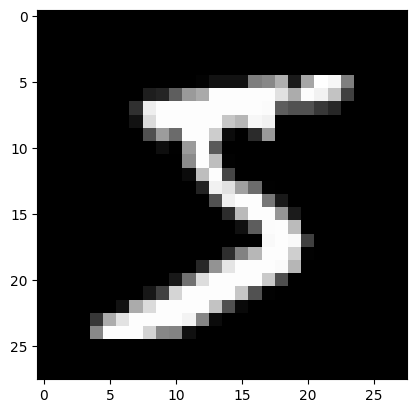

この数字は: 5 です


In [5]:
# データの読み込み（6万枚の学習データと1万枚のテスト用データ）
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# データの加工（AIが理解しやすいように0〜1の数値にする）
x_train, x_test = x_train / 255.0, x_test / 255.0

# どんな画像か1枚見てみる
plt.imshow(x_train[0], cmap='gray')
plt.show()
print("この数字は:", y_train[0], "です")

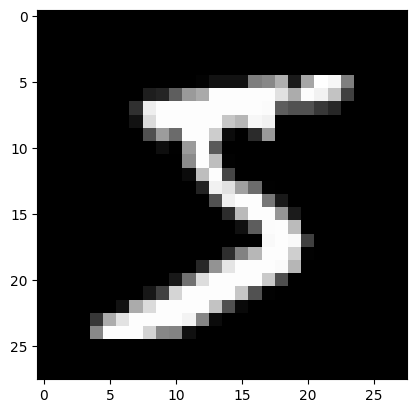

この数字は: 5 です


In [6]:
# データの読み込み（6万枚の学習データと1万枚のテスト用データ）
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# データの加工（AIが理解しやすいように0〜1の数値にする）
x_train, x_test = x_train / 255.0, x_test / 255.0

# どんな画像か1枚見てみる
plt.imshow(x_train[0], cmap='gray')
plt.show()
print("この数字は:", y_train[0], "です")

In [7]:
model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)), # 28x28の画像を1列の線にする
    layers.Dense(64, activation='relu'), # 128個のニューロンで考える
    layers.Dense(10, activation='softmax') # 最終的に0〜9のどれかを10個の確率で出す
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
model.fit(x_train, y_train, epochs=5) # 5回繰り返して学習

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8653 - loss: 0.4974
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9517 - loss: 0.1649
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9665 - loss: 0.1133
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9747 - loss: 0.0837
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9791 - loss: 0.0701


In [9]:
predictions = model.predict(x_test)
print("AIの予測:", predictions[0].argmax())
print("正解:", y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
AIの予測: 7
正解: 7


In [17]:
import cv2
import numpy as np

# 1. 画像を読み込む
img = cv2.imread('MNIST_3.PNG', cv2.IMREAD_GRAYSCALE)

# 2. 28x28ピクセルにリサイズする
img_resized = cv2.resize(img, (28, 28))

# 3. 白黒を反転させる（MNISTデータは背景が黒、文字が白なので）
img_final = cv2.bitwise_not(img_resized)

# 4. 0〜1の数値に変換し、AIが受け取れる形（1, 28, 28）に形を整える
img_final = img_final / 255.0
img_final = np.expand_dims(img_final, axis=0)

# 加工した画像を表示して確認
plt.imshow(img_final[0], cmap='gray')
plt.show()

error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'
